# Train/test leakage check (Comment 8)

Comment 8 asks whether the random (non-session-blocked) 85/10/5 split lets
near-identical configurations appear in both train and test, inflating
apparent generalization. Quantified here as nearest-neighbor distance, in
tendon-length (DELTAL) space, from each test sample to the full training set
-- a direct physical-configuration-similarity proxy. See `leakage_check.py`.

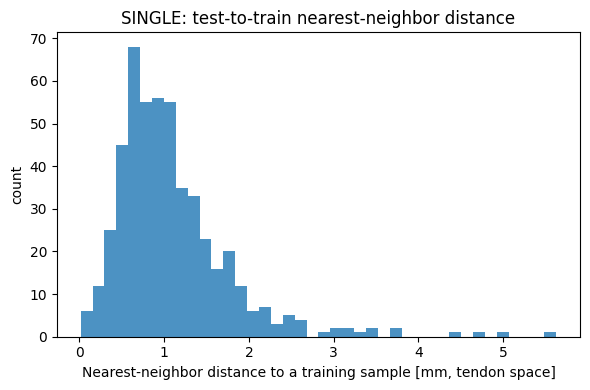

SINGLE (N=500): mean 1.10mm, median 0.95mm
  11.8% of test samples within 0.5mm of a training sample
  53.4% of test samples within 1.0mm of a training sample
  92.4% of test samples within 2.0mm of a training sample
For reference, the network's own reported test-set translation error is ~4mm --
so a large fraction of test points sit closer to a training point than the network's own error margin.


In [1]:

import numpy as np
import matplotlib.pyplot as plt

single_nn = np.load("results/leakage_nn_distance.npz")["nn_dist"]

fig, ax = plt.subplots(figsize=(6,4))
ax.hist(single_nn, bins=40, color="#1f77b4", alpha=0.8)
ax.set_xlabel("Nearest-neighbor distance to a training sample [mm, tendon space]")
ax.set_ylabel("count"); ax.set_title("SINGLE: test-to-train nearest-neighbor distance")
plt.tight_layout(); plt.savefig("results/single_leakage_nn.pdf"); plt.show()

print(f"SINGLE (N={len(single_nn)}): mean {single_nn.mean():.2f}mm, median {single_nn.median() if hasattr(single_nn,'median') else np.median(single_nn):.2f}mm")
for t in [0.5, 1.0, 2.0]:
    print(f"  {100*(single_nn<t).mean():.1f}% of test samples within {t}mm of a training sample")
print("For reference, the network's own reported test-set translation error is ~4mm --")
print("so a large fraction of test points sit closer to a training point than the network's own error margin.")


## MULTI

Note: the raw distance thresholds below aren't directly comparable to
SINGLE's (9-D combined tendon distance vs. 3-D), but the presence of *exact*
zero-distance duplicates is unambiguous either way.

MULTI (N=500): mean 4.72mm, median 5.01mm, min 0.0000mm
  28.2% of MULTI test samples are EXACT duplicates (distance = 0) of a training sample
  28.2% within 0.5mm


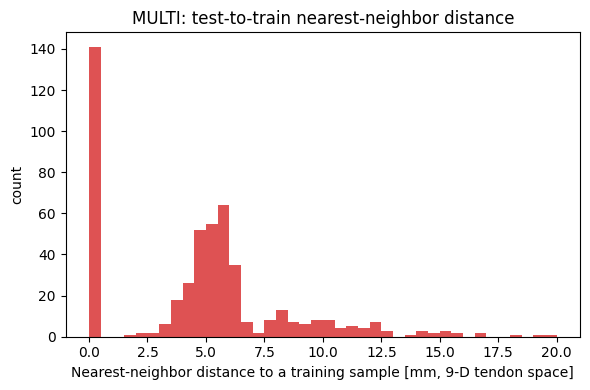

In [2]:

multi_nn = np.load("../MULTI/results/leakage_nn_distance.npz")["nn_dist"]
print(f"MULTI (N={len(multi_nn)}): mean {multi_nn.mean():.2f}mm, median {np.median(multi_nn):.2f}mm, min {multi_nn.min():.4f}mm")
print(f"  {100*(multi_nn < 1e-6).mean():.1f}% of MULTI test samples are EXACT duplicates (distance = 0) of a training sample")
print(f"  {100*(multi_nn < 0.5).mean():.1f}% within 0.5mm")

fig, ax = plt.subplots(figsize=(6,4))
ax.hist(multi_nn, bins=40, color="#d62728", alpha=0.8)
ax.set_xlabel("Nearest-neighbor distance to a training sample [mm, 9-D tendon space]")
ax.set_ylabel("count"); ax.set_title("MULTI: test-to-train nearest-neighbor distance")
plt.tight_layout(); plt.savefig("results/multi_leakage_nn.pdf"); plt.show()


**Reading**: this is likely a direct consequence of the SI's "statistically
balanced" sampling (Algorithm 1), which deliberately uses the Bending Solver
to enforce identical q-configurations across coupled modules for two of its
three sampling regimes -- a plausible mechanism for exact or near-exact
tendon-space duplicates ending up split across train/test by a
session-unaware random shuffle. This directly substantiates Comment 8's
concern with numbers, rather than just acknowledging it as a possibility.